# 1. Análisis Exploratorio de Datos
---

### 1. Introducción

**Objetivo del notebook.** Este notebook realiza el primer acercamiento exploratorio y
riguroso a los datos que soportarán la investigación sobre modelación predictiva de la
siniestralidad en seguros de automóviles. El propósito es describir la información
disponible —su estructura, calidad y comportamiento general— sin todavía construir,
ajustar ni evaluar ningún modelo predictivo.

**Contexto actuarial.** En seguros de responsabilidad civil de automóviles (Motor
Third-Party Liability, MTPL), la prima de riesgo de una póliza suele descomponerse como:

$$
\text{Prima pura} \approx \text{Frecuencia} \times \text{Severidad}
$$

- **Frecuencia**: número esperado de siniestros por unidad de exposición al riesgo.
- **Severidad**: costo monetario esperado de un siniestro, condicionado a que este ocurra.

Esta descomposición es la razón por la cual los datos se organizan en dos tablas
complementarias: una a nivel de póliza (para frecuencia) y otra a nivel de siniestro
(para severidad).

**Origen de los datos.** Se trabaja con el conjunto de datos público freMTPL2,
correspondiente a una cartera de pólizas reales de responsabilidad civil de automóviles en
Francia, observadas durante un período de aproximadamente un año. Este conjunto ha sido
ampliamente utilizado en la literatura actuarial y de aprendizaje automático aplicado a
seguros.


**Propósito del EDA dentro de la investigación.** 

Este análisis exploratorio busca:
1. Verificar la calidad estructural de los datos (dimensiones, tipos, duplicados, nulos).
2. Caracterizar de forma general las variables disponibles para frecuencia y severidad.
3. Detectar posibles inconsistencias que deberán abordarse en una
   etapa posterior de preprocesamiento.
4. Sentar las bases para el análisis univariado (Notebook 02) y, más adelante, para el
   análisis bivariado/multivariado y la modelación (GLM, Machine Learning, redes
   neuronales), que quedan explícitamente **fuera del alcance** de este notebook.

#### Diccionario de datos

El dataset **freMTPL2** contiene información relacionada con pólizas de seguros de automóviles de responsabilidad civil en Francia. Las variables permiten analizar las características del asegurado, del vehículo, la exposición al riesgo y los siniestros reportados.

| Columna | Tipo de variable | Descripción |
|---|---|---|
| **IDpol** | Identificador | Identificador único de la póliza. Permite relacionar la información de la póliza con los siniestros asociados. |
| **ClaimNb** | Numérica | Número de siniestros reportados por la póliza durante el período de observación. |
| **Exposure** | Numérica | Tiempo durante el cual la póliza estuvo expuesta al riesgo, expresado en años. Un valor de 1 representa un año completo de cobertura. |
| **Area** | Categórica | Categoría del área donde reside el asegurado, relacionada con el nivel de urbanización de la zona. |
| **VehPower** | Numérica / Ordinal | Nivel de potencia del vehículo. Valores más altos representan vehículos de mayor potencia. |
| **VehAge** | Numérica | Edad del vehículo, expresada en años. |
| **DrivAge** | Numérica | Edad del conductor asegurado, expresada en años. |
| **BonusMalus** | Numérica | Factor utilizado para ajustar la prima según el historial de siniestralidad del conductor. Valores más altos generalmente representan un mayor nivel de riesgo. |
| **VehBrand** | Categórica | Marca o grupo de marca del vehículo. Las marcas se encuentran codificadas mediante categorías como B1, B2, B3, etc. |
| **VehGas** | Categórica | Tipo de combustible utilizado por el vehículo: gasolina (Regular) o diésel (Diesel). |
| **Density** | Numérica | Densidad de población de la zona donde reside el asegurado, medida en habitantes por km². |
| **Region** | Categórica | Región de Francia donde reside el asegurado. |
| **ClaimAmount** | Numérica | Monto monetario asociado a un siniestro. Esta variable pertenece al **dataset de `severidad` y no al dataset principal de `frecuencia`.|



### 2. Importación de librerías

Se importan únicamente las librerías necesarias para el análisis exploratorio y descriptivo.

In [3]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sys.path.append(str(Path("..").resolve()))
from src.utils import (
    set_plot_style, load_freq, load_sev,
    resumen_numerico, tabla_frecuencias, resumen_categorico,
    hist_box, barplot_top_categorias,
)

set_plot_style()
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42  # fijado por reproducibilidad, aunque en este notebook no se muestrea

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


### 3. Carga de datos

Se cargan las dos tablas del conjunto:

- `freMTPL2freq.csv`: variables de riesgo y número de siniestros por póliza.
- `freMTPL2sev.csv`: monto total de siniestros agregado por póliza.


In [4]:
df_freq = load_freq("freMTPL2freq.csv")
df_sev = load_sev("freMTPL2sev.csv")

print(f"freMTPL2freq: {df_freq.shape[0]:,} filas x {df_freq.shape[1]} columnas")
print(f"freMTPL2sev : {df_sev.shape[0]:,} filas x {df_sev.shape[1]} columnas")


freMTPL2freq: 678,007 filas x 12 columnas
freMTPL2sev : 24,938 filas x 2 columnas


### 4. Inspección inicial

Se examinan dimensiones, primeras y últimas observaciones, nombres de columnas, tipos de datos y uso de memoria de ambas tablas.

In [5]:
print("Dimensiones freMTPL2freq:", df_freq.shape)
print("Dimensiones freMTPL2sev :", df_sev.shape)


Dimensiones freMTPL2freq: (678007, 12)
Dimensiones freMTPL2sev : (24938, 2)


In [6]:
df_freq.head()

,IDpol,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimNb
0,1,0.1000,D,5,0,55,50,B12,Regular,1217,R82,0
1,3,0.7700,D,5,0,55,50,B12,Regular,1217,R82,0
2,5,0.7500,B,6,2,52,50,B12,Diesel,54,R22,0
3,10,0.0900,B,7,0,46,50,B12,Diesel,76,R72,0
4,11,0.8400,B,7,0,46,50,B12,Diesel,76,R72,0


In [7]:
df_freq.tail()

,IDpol,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ClaimNb
678002,6114326,0.0027,E,4,0,54,50,B12,Regular,3317,R93,0
678003,6114327,0.0027,E,4,0,41,95,B12,Regular,9850,R11,0
678004,6114328,0.0027,D,6,2,45,50,B12,Diesel,1323,R82,0
678005,6114329,0.0027,B,4,0,60,50,B12,Regular,95,R26,0
678006,6114330,0.0027,B,7,6,29,54,B12,Diesel,65,R72,0


In [8]:
df_sev.head()

,IDpol,ClaimAmount
0,139,303.0000
1,190,"1,981.8400"
2,414,"1,456.5500"
3,424,"10,834.0000"
4,463,"3,986.6700"


In [9]:
df_sev.tail()

,IDpol,ClaimAmount
24933,6113521,"1,324.4000"
24934,6113793,"1,769.8800"
24935,6113817,"1,288.2800"
24936,6113834,"12,230.4000"
24937,6113971,"1,452.0000"


In [10]:
print("Columnas freMTPL2freq:", list(df_freq.columns))
print("Columnas freMTPL2sev :", list(df_sev.columns))


Columnas freMTPL2freq: ['IDpol', 'Exposure', 'Area', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region', 'ClaimNb']
Columnas freMTPL2sev : ['IDpol', 'ClaimAmount']


In [11]:
df_freq.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 678007 entries, 0 to 678006
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       678007 non-null  int64  
 1   Exposure    678007 non-null  float64
 2   Area        678007 non-null  object 
 3   VehPower    678007 non-null  int64  
 4   VehAge      678007 non-null  int64  
 5   DrivAge     678007 non-null  int64  
 6   BonusMalus  678007 non-null  int64  
 7   VehBrand    678007 non-null  object 
 8   VehGas      678007 non-null  object 
 9   Density     678007 non-null  int64  
 10  Region      678007 non-null  object 
 11  ClaimNb     678007 non-null  int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 197.1 MB


In [12]:
df_sev.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24938 entries, 0 to 24937
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   IDpol        24938 non-null  int64  
 1   ClaimAmount  24938 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 389.8 KB


**Interpretación.** 

El conjunto de datos contiene 678.007 pólizas (una fila por póliza) con 12 columnas: el identificador IDpol, la variable de exposición al riesgo Exposure, ocho variables de riesgo del vehículo y del conductor (Area, VehPower, VehAge, DrivAge, BonusMalus, VehBrand, VehGas, Density, Region) y la variable objetivo de frecuencia ClaimNb. Adicionalmente, se cuenta con 24.938 registros de siniestros con dos columnas (IDpol, ClaimAmount), correspondientes a las pólizas que presentaron al menos un siniestro con monto positivo. Ninguna de las dos tablas presenta valores nulos declarados a nivel de columna.

### 5. Estructura de las bases

Se clasifican las variables según su naturaleza para orientar el resto del análisis.
Esta clasificación es descriptiva y no implica ninguna decisión de modelación.


In [13]:
clasificacion_freq = pd.DataFrame({
    "variable": df_freq.columns,
    "dtype": df_freq.dtypes.astype(str).values,
    "tipo_conceptual": [
        "Identificador de póliza",           # IDpol
        "Numérica continua (exposición)",    # Exposure
        "Categórica (código de área)",       # Area
        "Numérica discreta/ordinal",         # VehPower
        "Numérica discreta",                 # VehAge
        "Numérica discreta",                 # DrivAge
        "Numérica discreta",                 # BonusMalus
        "Categórica (marca)",                # VehBrand
        "Categórica (tipo de combustible)",  # VehGas
        "Numérica continua",                 # Density
        "Categórica (región)",               # Region
        "Numérica discreta (variable objetivo frecuencia)",  # ClaimNb
    ],
})
clasificacion_freq


,variable,dtype,tipo_conceptual
0,IDpol,int64,Identificador de póliza
1,Exposure,float64,Numérica continua (exposición)
2,Area,object,Categórica (código de área)
3,VehPower,int64,Numérica discreta/ordinal
4,VehAge,int64,Numérica discreta
5,DrivAge,int64,Numérica discreta
6,BonusMalus,int64,Numérica discreta
7,VehBrand,object,Categórica (marca)
8,VehGas,object,Categórica (tipo de combustible)
9,Density,int64,Numérica continua


In [14]:
clasificacion_sev = pd.DataFrame({
    "variable": df_sev.columns,
    "dtype": df_sev.dtypes.astype(str).values,
    "tipo_conceptual": [
        "Identificador de póliza (llave de relación con freMTPL2freq)",
        "Numérica continua (variable objetivo severidad)",
    ],
})
clasificacion_sev


,variable,dtype,tipo_conceptual
0,IDpol,int64,Identificador de póliza (llave de relación con...
1,ClaimAmount,float64,Numérica continua (variable objetivo severidad)


### 6. Estadística descriptiva inicial

Se presentan estadísticas descriptivas (conteo, media, desviación estándar, mínimo,
percentiles, mediana, máximo) para las variables numéricas, y frecuencias absolutas y
relativas para las variables categóricas.


In [15]:
num_cols_freq = ["Exposure", "VehPower", "VehAge", "DrivAge", "BonusMalus", "Density", "ClaimNb"]
resumen_numerico(df_freq, num_cols_freq)


,count,mean,std,min,1%,25%,50%,75%,99%,max,skew,missing,missing_%
Exposure,"678,007.0000",0.5290,0.3640,0.0030,0.0080,0.1800,0.4900,0.9900,1.0000,1.0000,0.0820,0,0.0000
VehPower,"678,007.0000",6.4550,2.0510,4.0000,4.0000,5.0000,6.0000,7.0000,13.0000,15.0000,1.1710,0,0.0000
VehAge,"678,007.0000",7.0440,5.6660,0.0000,0.0000,2.0000,6.0000,11.0000,21.0000,100.0000,1.1480,0,0.0000
DrivAge,"678,007.0000",45.4990,14.1370,18.0000,20.0000,34.0000,44.0000,55.0000,80.0000,100.0000,0.4360,0,0.0000
BonusMalus,"678,007.0000",59.7620,15.6370,50.0000,50.0000,50.0000,50.0000,64.0000,106.0000,230.0000,1.7290,0,0.0000
Density,"678,007.0000","1,792.4310","3,958.6630",1.0000,10.0000,92.0000,393.0000,"1,658.0000","27,000.0000","27,000.0000",4.6510,0,0.0000
ClaimNb,"678,007.0000",0.0390,0.2050,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,5.0000,5.6430,0,0.0000


In [16]:
resumen_numerico(df_sev, ["ClaimAmount"])

,count,mean,std,min,1%,25%,50%,75%,99%,max,skew,missing,missing_%
ClaimAmount,"24,938.0000","2,397.0480","30,266.6190",1.0000,39.8750,749.2620,"1,172.0000","1,346.3600","17,960.2370","4,075,400.5600",106.1510,0,0.0000


In [17]:
cat_cols_freq = ["Area", "VehBrand", "VehGas", "Region"]
resumen_categorico(df_freq, cat_cols_freq)


,n_categorias,categoria_dominante,peso_categoria_dominante_%,categoria_menos_frecuente,peso_categoria_menos_frecuente_%
variable,,,,,
Area,6,C,28.3000,F,2.6481
VehBrand,11,B12,24.4900,B14,0.5969
VehGas,2,Regular,51.0100,Diesel,48.9871
Region,22,R24,23.6900,R43,0.1956


**Interpretación.** 

Las variables numéricas presentan escalas diferentes entre sí. Por ejemplo, Exposure toma valores entre 0 y 1, mientras que Density puede alcanzar valores de miles de habitantes por km². Estas diferencias de escala deberán tenerse en cuenta en etapas posteriores de modelación, aunque no se realizará ninguna transformación en esta etapa. Entre las variables categóricas, VehGas es binaria, mientras que Region y VehBrand presentan un mayor número de categorías. Por su parte, Area está compuesta por 6 categorías.

La variable ClaimAmount, correspondiente al monto de los siniestros, presenta una media superior a la mediana. Esto indica que existen algunos siniestros con valores considerablemente altos y sugiere una distribución sesgada hacia la derecha, característica frecuente en los datos de severidad de seguros.

### 7. Variables numéricas

Esta sección ofrece un panorama general de las variables numéricas de `ambos datasets.


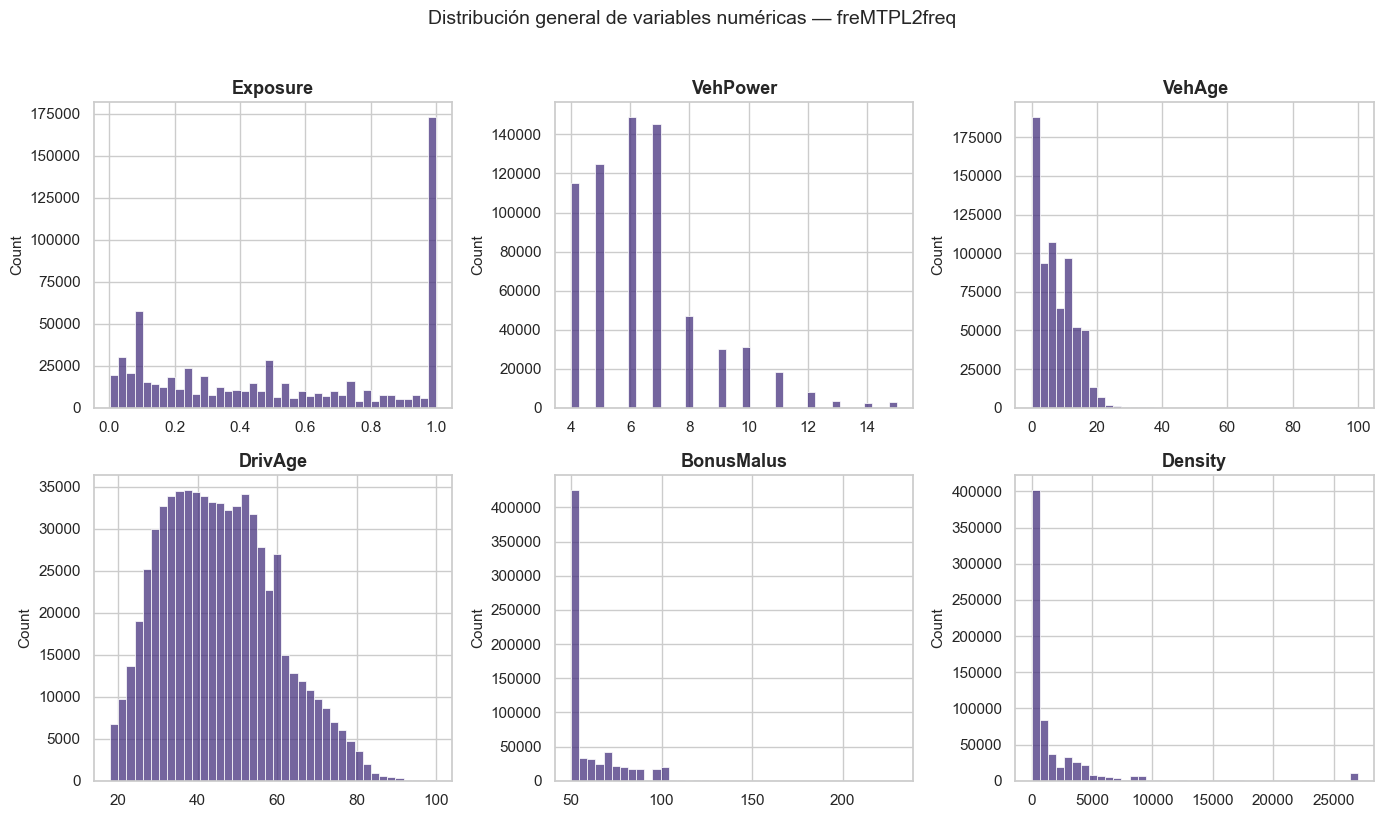

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), ["Exposure", "VehPower", "VehAge", "DrivAge", "BonusMalus", "Density"]):
    sns.histplot(df_freq[col], bins=40, ax=ax, kde=False)
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Distribución general de variables numéricas — freMTPL2freq", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


**Interpretación general.** 

En la distribución de **Exposure** se observa una concentración importante de observaciones en el valor 1, lo que indica que una gran parte de las pólizas estuvieron expuestas al riesgo durante un año completo. También se presentan valores menores, correspondientes a pólizas con períodos de cobertura más cortos.

La variable **VehPower** presenta una distribución discreta, concentrándose principalmente entre los valores 4 y 8. A partir de estos valores la frecuencia disminuye progresivamente, aunque todavía se encuentran algunos vehículos con mayor potencia. Esto muestra que la mayoría de los vehículos de la muestra se encuentran en niveles de potencia relativamente bajos o medios.

En cuanto a **VehAge**, la distribución se concentra principalmente en vehículos relativamente jóvenes, especialmente en los primeros años de antigüedad. La frecuencia disminuye conforme aumenta la edad del vehículo, aunque se observan algunos casos de vehículos considerablemente más antiguos. Por lo tanto, presenta un claro sesgo hacia la derecha.

La variable **DrivAge** presenta una distribución más amplia y relativamente continua. La mayor concentración de conductores se encuentra aproximadamente entre los 30 y 60 años, con un pico alrededor de los 40 años. Después de los 60 años la frecuencia comienza a disminuir de manera gradual, aunque todavía existen conductores de edades más avanzadas.

Para **BonusMalus** se observa una concentración muy marcada alrededor del valor 50. Esto indica que una gran parte de las pólizas se encuentra en este nivel. A partir de este punto la frecuencia disminuye, aunque existen algunos valores considerablemente mayores. La distribución, por tanto, presenta una fuerte concentración en valores bajos y una cola hacia la derecha.

Finalmente, **Density** presenta una distribución fuertemente sesgada hacia la derecha. La mayoría de las observaciones corresponden a zonas con densidades relativamente bajas, mientras que un número reducido de casos presenta densidades muy altas. Esto genera una cola larga que llega a valores superiores a 20.000 habitantes por km². Por esta razón, la media de esta variable puede verse afectada por estos valores extremos y la mediana puede ser una medida más representativa de la tendencia central.

### 8. Variables categóricas

Se examina la cardinalidad y el desbalance de las variables categóricas presentes:
Area, VehBrand, VehGas y Region. Para variables con muchas categorías se
muestran únicamente las más frecuentes (*top-N*), indicándolo explícitamente.


In [19]:
tabla_frecuencias(df_freq, "Area")

,frecuencia_absoluta,frecuencia_relativa_%
Area,,
C,191880,28.3000
D,151590,22.3600
E,137167,20.2300
A,103957,15.3300
B,75459,11.1300
F,17954,2.6500


In [20]:
tabla_frecuencias(df_freq, "VehGas")

,frecuencia_absoluta,frecuencia_relativa_%
VehGas,,
Regular,345871,51.0100
Diesel,332136,48.9900


In [21]:
print(f"VehBrand tiene {df_freq['VehBrand'].nunique()} categorías. Se muestran las 11 disponibles (no se recorta):")
tabla_frecuencias(df_freq, "VehBrand")


VehBrand tiene 11 categorías. Se muestran las 11 disponibles (no se recorta):


,frecuencia_absoluta,frecuencia_relativa_%
VehBrand,,
B12,166024,24.4900
B1,162730,24.0000
B2,159861,23.5800
B3,53395,7.8800
B5,34753,5.1300
B6,28548,4.2100
B4,25179,3.7100
B10,17707,2.6100
B11,13585,2.0000


In [22]:
print(f"Region tiene {df_freq['Region'].nunique()} categorías. Se muestran únicamente las 10 más frecuentes (top-10):")
tabla_frecuencias(df_freq, "Region", top_n=10)


Region tiene 22 categorías. Se muestran únicamente las 10 más frecuentes (top-10):


,frecuencia_absoluta,frecuencia_relativa_%
Region,,
R24,160601,23.6900
R82,84752,12.5000
R93,79315,11.7000
R11,69791,10.2900
R53,42122,6.2100
R52,38751,5.7200
R91,35799,5.2800
R72,31329,4.6200
R31,27285,4.0200


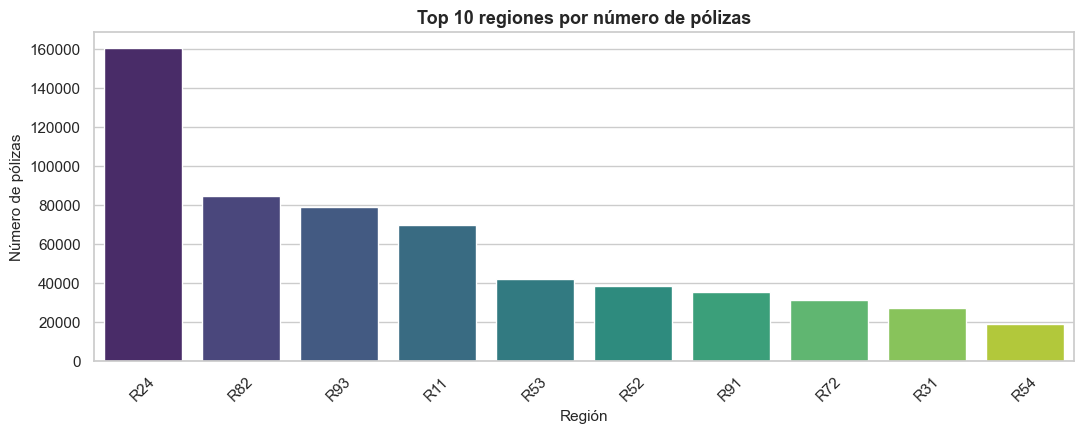

In [23]:
barplot_top_categorias(df_freq, "Region", top_n=10,
                       titulo="Top 10 regiones por número de pólizas",
                       xlabel="Región")


**Interpretación.** 

Las variables **Area** y **VehGas** presentan una baja cantidad de categorías, con 6 y 2 categorías respectivamente. Esto permite analizar la distribución completa de sus valores sin necesidad de realizar agrupaciones para la visualización.

Por su parte, **VehBrand** cuenta con 11 categorías, por lo que también resulta manejable para analizarse en su totalidad. En el caso de **Region**, se tienen 22 categorías, por lo que para facilitar la visualización puede ser conveniente mostrar únicamente las regiones con mayor frecuencia. Sin embargo, para el análisis tabular se mantienen todas las categorías.

En general, se observa que las pólizas no se distribuyen de manera completamente uniforme entre las regiones, sino que existe una mayor concentración en algunas de ellas. Esta distribución geográfica puede ser relevante en etapas posteriores, ya que la región puede estar relacionada con características del entorno, como la densidad poblacional, y potencialmente con el comportamiento de la frecuencia de siniestros.

### 9. Relación estructural entre tablas

Se analiza cómo se relacionan `freMTPL2freq` y `freMTPL2sev` a través de la llave común IDpol.


In [30]:
n_polizas = df_freq["IDpol"].nunique()
n_polizas_con_siniestro_segun_freq = (df_freq["ClaimNb"] > 0).sum()
n_polizas_con_registro_en_sev = df_sev["IDpol"].nunique()
n_registros_sev = len(df_sev)
duplicados_idpol_sev = df_sev["IDpol"].duplicated().sum()
duplicados_idpol_freq = df_freq["IDpol"].duplicated().sum()

resumen_relacion = pd.DataFrame({
    "métrica": [
        "Pólizas únicas en freMTPL2freq",
        "Pólizas con ClaimNb > 0 (según freMTPL2freq)",
        "Pólizas únicas presentes en freMTPL2sev",
        "Registros totales en freMTPL2sev",
        "IDpol duplicados en freMTPL2freq",
        "IDpol duplicados en freMTPL2sev",
    ],
    "valor": [
        n_polizas, n_polizas_con_siniestro_segun_freq,
        n_polizas_con_registro_en_sev, n_registros_sev,
        duplicados_idpol_freq, duplicados_idpol_sev,
    ],
})
resumen_relacion


,métrica,valor
0,Pólizas únicas en freMTPL2freq,678007
1,Pólizas con ClaimNb > 0 (según freMTPL2freq),24938
2,Pólizas únicas presentes en freMTPL2sev,24938
3,Registros totales en freMTPL2sev,24938
4,IDpol duplicados en freMTPL2freq,0
5,IDpol duplicados en freMTPL2sev,0


In [31]:
ids_freq = set(df_freq["IDpol"])
ids_sev = set(df_sev["IDpol"])

en_sev_no_en_freq = ids_sev - ids_freq
en_freq_con_claimnb_pero_no_en_sev = {
    idpol for idpol in df_freq.loc[df_freq["ClaimNb"] > 0, "IDpol"] if idpol not in ids_sev
}

print(f"IDpol en freMTPL2sev que NO existen en freMTPL2freq: {len(en_sev_no_en_freq)}")
print(f"Pólizas con ClaimNb > 0 en freMTPL2freq que NO tienen registro en freMTPL2sev: "
      f"{len(en_freq_con_claimnb_pero_no_en_sev)}")


IDpol en freMTPL2sev que NO existen en freMTPL2freq: 0
Pólizas con ClaimNb > 0 en freMTPL2freq que NO tienen registro en freMTPL2sev: 0


No se identifican valores duplicados de IDpol dentro de freMTPL2freq, ya que esta tabla contiene una fila por póliza. Finalmente, el cruce de identificadores no muestra pólizas de freMTPL2sev que estén ausentes en freMTPL2freq, lo que indica una relación adecuada entre ambas tablas.

### 10. Diagnóstico exploratorio de consistencia

Se realiza una primera inspección de valores potencialmente problemáticos. 


In [32]:
diagnosticos = []

def registrar(nombre, condicion):
    n = int(condicion.sum())
    diagnosticos.append({
        "chequeo": nombre,
        "n_registros": n,
        "%_del_total": round(n / len(df_freq) * 100, 4),
    })

registrar("Exposure < 0", df_freq["Exposure"] < 0)
registrar("Exposure > 1", df_freq["Exposure"] > 1)
registrar("VehAge < 0", df_freq["VehAge"] < 0)
registrar("VehAge > 50 (valor atípicamente alto)", df_freq["VehAge"] > 50)
registrar("DrivAge < 18 (edad mínima legal de conducción en Francia)", df_freq["DrivAge"] < 18)
registrar("DrivAge > 90 (valor atípicamente alto)", df_freq["DrivAge"] > 90)
registrar("VehPower <= 0", df_freq["VehPower"] <= 0)
registrar("BonusMalus < 50 (por debajo del mínimo legal típico)", df_freq["BonusMalus"] < 50)
registrar("BonusMalus > 150 (malus elevado)", df_freq["BonusMalus"] > 150)
registrar("Density > 20000 hab/km² (extremadamente alta)", df_freq["Density"] > 20000)

diagnostico_freq = pd.DataFrame(diagnosticos)
diagnostico_freq


,chequeo,n_registros,%_del_total
0,Exposure < 0,0,0.0000
1,Exposure > 1,0,0.0000
2,VehAge < 0,0,0.0000
3,VehAge > 50 (valor atípicamente alto),97,0.0143
4,DrivAge < 18 (edad mínima legal de conducción ...,0,0.0000
5,DrivAge > 90 (valor atípicamente alto),401,0.0591
6,VehPower <= 0,0,0.0000
7,BonusMalus < 50 (por debajo del mínimo legal t...,0,0.0000
8,BonusMalus > 150 (malus elevado),209,0.0308
9,Density > 20000 hab/km² (extremadamente alta),11302,1.6669


In [33]:
n_claimamount_no_positivo = int((df_sev["ClaimAmount"] <= 0).sum())
print(f"Registros con ClaimAmount <= 0 en freMTPL2sev: {n_claimamount_no_positivo} "
      f"({n_claimamount_no_positivo / len(df_sev) * 100:.4f}% del total)")


Registros con ClaimAmount <= 0 en freMTPL2sev: 0 (0.0000% del total)


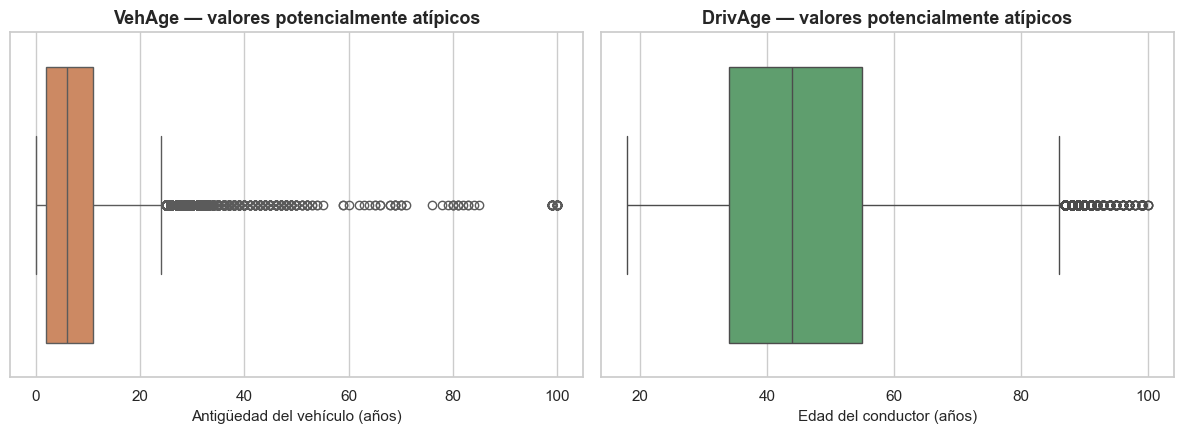

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.boxplot(x=df_freq["VehAge"], ax=axes[0], color="#DD8452")
axes[0].set_title("VehAge — valores potencialmente atípicos")
axes[0].set_xlabel("Antigüedad del vehículo (años)")

sns.boxplot(x=df_freq["DrivAge"], ax=axes[1], color="#55A868")
axes[1].set_title("DrivAge — valores potencialmente atípicos")
axes[1].set_xlabel("Edad del conductor (años)")

plt.tight_layout()
plt.show()


**Interpretación.** 

En la exploración de valores atípicos se observan diferencias entre las dos variables. VehAge presenta varios valores potencialmente atípicos, especialmente para vehículos con edades muy superiores a la mayoría de la muestra. En DrivAge también aparecen algunos valores atípicos, principalmente en las edades más altas. Sin embargo, estos valores no necesariamente representan errores, por lo que en esta etapa se identifican únicamente como posibles outliers y no se eliminan.

### 11. Mapa de correlación



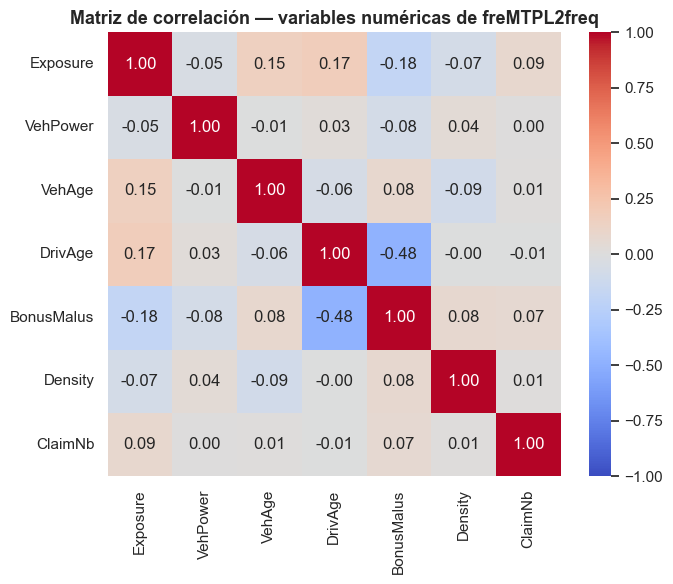

In [36]:
num_cols_corr = ["Exposure", "VehPower", "VehAge", "DrivAge", "BonusMalus", "Density", "ClaimNb"]
corr = df_freq[num_cols_corr].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title("Matriz de correlación — variables numéricas de freMTPL2freq")
plt.tight_layout()
plt.show()


**Interpretación.**

La matriz muestra que, en general, las variables numéricas tienen correlaciones bajas entre sí. La relación más notable se encuentra entre DrivAge y BonusMalus, con una correlación negativa moderada de -0.48, lo que indica que a mayor edad del conductor tiende a observarse un menor valor de BonusMalus. Con respecto a ClaimNb, las correlaciones con las demás variables son muy bajas, por lo que no se observa una relación lineal fuerte entre el número de siniestros y ninguna de estas variables de forma individual. En general, no se evidencian problemas importantes de correlación entre las variables numéricas.

### 12. Hallazgos principales

1. freMTPL2freq contiene 678.007 pólizas y no presenta valores nulos declarados. Las variables incluyen información sobre el vehículo, el conductor y la ubicación de la póliza.
2. freMTPL2sev contiene 24.938 registros con el monto total de los siniestros por póliza. Se documentó que esta versión está agregada, por lo que difiere de la tabla oficial no agregada de CASdatasets.
3. La frecuencia de siniestros es baja: más del 96% de las pólizas no reportan ningún siniestro durante el período observado.
4. ClaimAmount presenta una distribución bastante sesgada hacia la derecha. La mayoría de los siniestros tienen montos relativamente bajos, mientras que unos pocos presentan valores mucho más altos.
5. Se encontraron valores potencialmente atípicos en VehAge y DrivAge, principalmente en los valores más altos. Estos casos deberán revisarse posteriormente, aunque no necesariamente representan errores en los datos.
6. Exposure se encuentra dentro del rango esperado de 0 a 1 para todas las pólizas analizadas.
7. Las variables categóricas tienen una cantidad de categorías que permite analizarlas sin mayores dificultades. Area, VehGas y VehBrand presentan pocas categorías, mientras que Region tiene una cantidad moderada.

### 15. Conclusiones del EDA

Este análisis exploratorio permite concluir que los datos de freMTPL2 tienen una estructura adecuada para desarrollar la investigación sobre la modelación predictiva de la siniestralidad. Se identificaron variables relacionadas con las características del vehículo, el conductor y la ubicación que pueden ser útiles para explicar la frecuencia de siniestros, además de realizar una primera revisión del comportamiento de la severidad.

También se dejaron documentadas algunas características importantes de los datos, como la agregación de la tabla de severidad y la presencia de valores potencialmente atípicos en las variables de edad. En esta etapa no se realizaron correcciones sobre estos casos, ya que serán revisados posteriormente durante el preprocesamiento.

Los resultados obtenidos servirán como punto de partida para el Notebook 2. Análisis Univariado y para las siguientes etapas del proyecto, donde se profundizará en las relaciones entre las variables y posteriormente en el preprocesamiento y la modelación.
